# Forecasting website traffic

Capacity planning, marketing budgets and revenue targets all start with a
forecast. This notebook forecasts daily visits to a product website four
weeks ahead, and covers what makes forecasting different from ordinary
machine learning:

1. Cleaning: gaps and outages
2. Seeing the patterns: trend, weekly and yearly cycles, one-off events
3. Baselines that are surprisingly hard to beat
4. Two real models: Holt-Winters and a regression with calendar features
5. Backtesting: judging a forecast over many past periods, not one
6. Prediction intervals: forecasts are ranges, not single numbers

The data is three years of simulated daily traffic with a few things built
in: steady growth, a weekday/weekend pattern, a quiet holiday season, a
product launch that permanently lifted traffic, and a three-day outage.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL

from sample_data import web_traffic

plt.rcParams.update({"figure.figsize": (11, 4), "axes.spines.top": False, "axes.spines.right": False})
visits = web_traffic()
print(f"{len(visits):,} days from {visits.index.min():%Y-%m-%d} to {visits.index.max():%Y-%m-%d}")
print(f"Missing days: {visits.isna().sum()} -> {list(visits[visits.isna()].index.strftime('%Y-%m-%d'))}")

1,096 days from 2022-07-01 to 2025-06-30
Missing days: 3 -> ['2023-04-11', '2023-04-12', '2023-04-13']


## 1. Cleaning

Three days are missing: tracking broke during an outage. Most forecasting
methods need an unbroken series, so we fill the gap. Filling with zero would
teach the model that traffic sometimes collapses; filling with the same
weekday from the week before keeps the weekly shape. We keep a flag so we
remember these values are invented.

Filled 3 days using the same weekday a week earlier


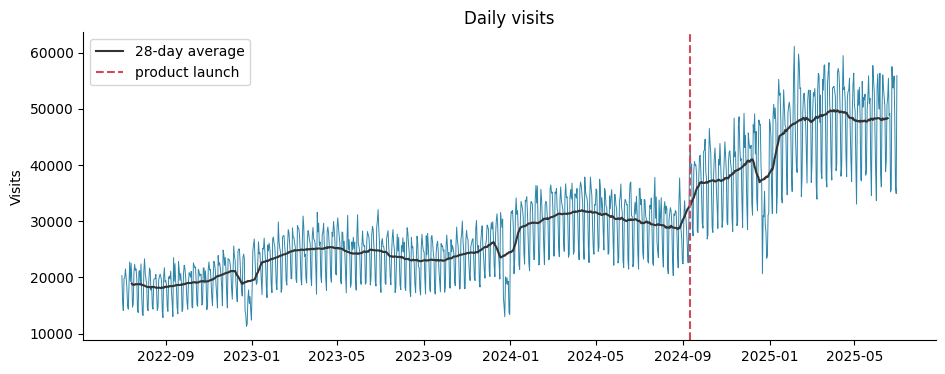

In [ ]:
was_missing = visits.isna()
visits = visits.fillna(visits.shift(7))
print(f"Filled {was_missing.sum()} days using the same weekday a week earlier")

fig, ax = plt.subplots()
ax.plot(visits.index, visits, linewidth=0.7, color="#2e86ab")
ax.plot(visits.rolling(28, center=True).mean(), color="#333", label="28-day average")
ax.axvline(pd.Timestamp("2024-09-10"), color="#d1495b", linestyle="--", label="product launch")
ax.set(title="Daily visits", ylabel="Visits")
ax.legend();

Even before any modelling, the chart shows a lot: steady growth, a dip every
late December, and a jump in September 2024 that never goes away. That jump
was a product launch. A model that doesn't know about it will be confused,
so we'll tell it.

## 2. Taking the series apart

**STL decomposition** splits a series into a trend, a repeating seasonal
pattern and what's left over. We decompose the *log* of visits, which turns
"weekends are 25% lower" into a fixed shift. That's more natural for traffic
that grows over time.

Traffic by weekday, relative to an average day:
  Mon 1.11  Tue 1.16  Wed 1.14  Thu 1.10  Fri 1.02  Sat 0.80  Sun 0.76


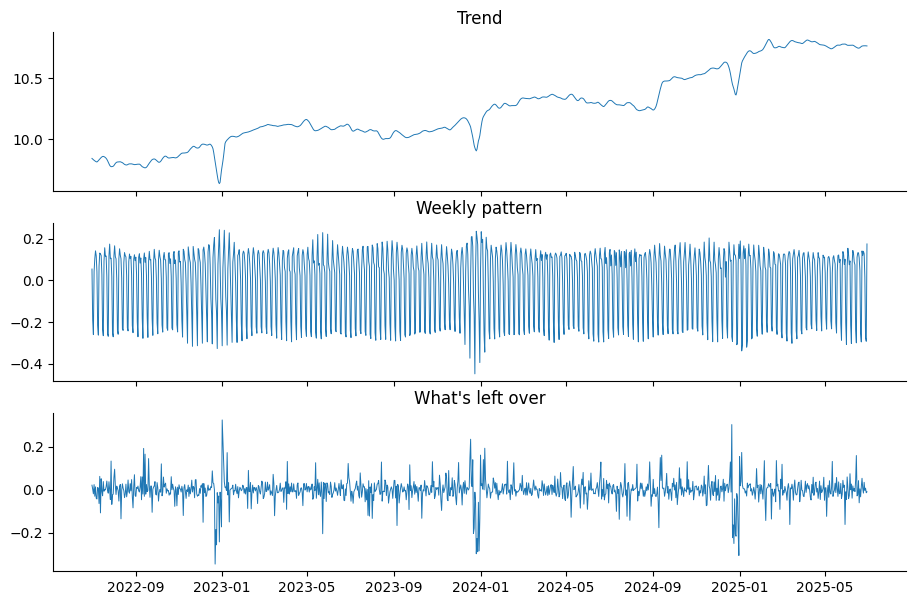

In [ ]:
stl = STL(np.log(visits), period=7, robust=True).fit()
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
for ax, part, title in zip(axes, [stl.trend, stl.seasonal, stl.resid],
                           ["Trend", "Weekly pattern", "What's left over"], strict=True):
    ax.plot(part.index, part, linewidth=0.7)
    ax.set_title(title)

weekday_effect = np.exp(stl.seasonal.groupby(visits.index.dayofweek).mean())
print("Traffic by weekday, relative to an average day:")
print("  " + "  ".join(f"{d} {v:.2f}" for d, v in zip(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
                                                         weekday_effect, strict=True)))

Weekdays run well above weekends, which tells us this is a work tool rather
than a consumer site. The leftover panel shows the December dips and the
launch step as spikes: things a weekly pattern can't explain and a model will
need help with.

## 3. Baselines first

Before any clever model, measure two simple forecasts. If a model can't beat
them, it isn't worth the complexity.

- **Naive:** tomorrow equals today.
- **Seasonal naive:** each day equals the same weekday last week.

We forecast the last 28 days, having trained on everything before them, and
score with MAPE (average percentage error).

In [ ]:
HORIZON = 28
LAUNCH = pd.Timestamp("2024-09-10")


def mape(actual, forecast):
    return float(np.mean(np.abs((actual - forecast) / actual)))


def naive(train, horizon):
    return np.repeat(train.iloc[-1], horizon)


def seasonal_naive(train, horizon):
    last_week = train.iloc[-7:].to_numpy()
    return np.tile(last_week, horizon // 7 + 1)[:horizon]


train, test = visits.iloc[:-HORIZON], visits.iloc[-HORIZON:]
for name, fn in [("Naive", naive), ("Seasonal naive", seasonal_naive)]:
    print(f"{name:<16} MAPE {mape(test, fn(train, HORIZON)):.1%}")

Naive            MAPE 16.7%
Seasonal naive   MAPE 6.3%


Seasonal naive is far better, because it copies the weekly shape. It's the
baseline to beat.

## 4. Two real models

**Holt-Winters** (exponential smoothing) keeps running estimates of the
level, trend and weekly pattern, weighting recent days more. It adapts on its
own and needs no feature engineering.

**Regression with calendar features** describes the log of traffic as a
trend, plus a weekday effect, plus a smooth yearly cycle, plus a holiday flag
and a launch flag. It needs more setup, but every part is explainable, and
it can be told about known events.

Seasonal naive               MAPE 6.3%
Holt-Winters                 MAPE 4.2%
Regression, no launch flag   MAPE 8.1%
Regression with launch flag  MAPE 4.2%


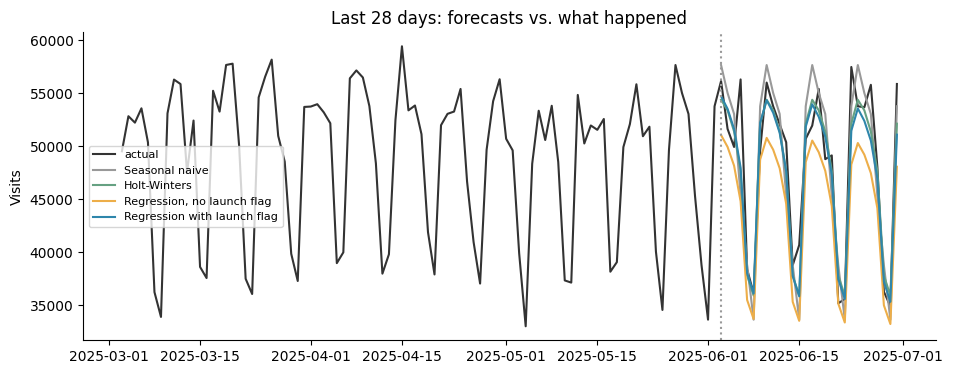

In [ ]:
def holt_winters(train, horizon):
    model = ExponentialSmoothing(np.log(train), trend="add", damped_trend=True, seasonal="add",
                                 seasonal_periods=7).fit()
    return np.exp(model.forecast(horizon)).to_numpy()


def calendar_features(index):
    days = (index - pd.Timestamp("2022-07-01")).days.to_numpy()
    yearly = 2 * np.pi * index.dayofyear.to_numpy() / 365.25
    features = pd.DataFrame({
        "trend": days,
        "sin_year": np.sin(yearly), "cos_year": np.cos(yearly),
        "holidays": ((index.month == 12) & (index.day >= 22)).astype(int),
        "after_launch": (index >= LAUNCH).astype(int),
    }, index=index)
    weekdays = pd.get_dummies(index.dayofweek, prefix="dow", drop_first=True, dtype=int)
    weekdays.index = index
    return features.join(weekdays)


def calendar_regression(train, horizon, use_launch=True):
    future = pd.date_range(train.index[-1] + pd.Timedelta(days=1), periods=horizon, freq="D")
    X_train, X_future = calendar_features(train.index), calendar_features(future)
    if not use_launch:
        X_train, X_future = X_train.drop(columns="after_launch"), X_future.drop(columns="after_launch")
    model = LinearRegression().fit(X_train, np.log(train))
    return np.exp(model.predict(X_future))


forecasts = {
    "Seasonal naive": seasonal_naive(train, HORIZON),
    "Holt-Winters": holt_winters(train, HORIZON),
    "Regression, no launch flag": calendar_regression(train, HORIZON, use_launch=False),
    "Regression with launch flag": calendar_regression(train, HORIZON),
}
for name, f in forecasts.items():
    print(f"{name:<28} MAPE {mape(test, f):.1%}")

fig, ax = plt.subplots()
ax.plot(visits.iloc[-120:], color="#333", label="actual")
for (name, f), color in zip(forecasts.items(), ["#999", "#66a182", "#edae49", "#2e86ab"], strict=True):
    ax.plot(test.index, f, color=color, label=name)
ax.axvline(test.index[0], color="#999", linestyle=":")
ax.set(title="Last 28 days: forecasts vs. what happened", ylabel="Visits")
ax.legend(fontsize=8);

Leaving the launch out of the regression makes it worse: it has to explain
the jump with its trend line, which then runs too steep or too shallow. When
you know about an event (a launch, a price change, a marketing campaign),
give the model a feature for it rather than hoping it works it out.

## 5. Backtesting

One 28-day window can flatter or punish a model by luck. A **backtest**
repeats the exercise from many past cut-off dates, always training only on
data before the cut-off, the same way the forecast would have been made at
the time.

In [ ]:
cutoffs = pd.date_range("2024-01-01", visits.index[-HORIZON - 1], freq="45D")
methods = {"Seasonal naive": seasonal_naive, "Holt-Winters": holt_winters,
           "Regression with launch flag": calendar_regression}
scores = {name: [] for name in methods}
for cutoff in cutoffs:
    past = visits.loc[:cutoff]
    actual = visits.loc[cutoff + pd.Timedelta(days=1):].iloc[:HORIZON]
    for name, fn in methods.items():
        scores[name].append(mape(actual, fn(past, HORIZON)))

backtest = pd.DataFrame(scores, index=cutoffs.strftime("%Y-%m-%d"))
print(f"MAPE over {len(cutoffs)} backtest windows:")
print(backtest.agg(["mean", "median", "max"]).T.map("{:.1%}".format).to_string())

MAPE over 12 backtest windows:
                              mean median    max
Seasonal naive               10.6%   6.5%  34.3%
Holt-Winters                  8.9%   5.4%  29.9%
Regression with launch flag   4.0%   4.1%   5.5%


Look at the worst case as well as the average. Holt-Winters and seasonal
naive do fine in ordinary weeks but miss by around 30% in the two windows
that start just after Christmas: they have just seen the holiday dip and
carry it forward into January, when traffic has already bounced back. The
regression knows the dip is a holiday, so its worst window is barely worse
than its typical one. For planning, that
steadiness is often worth more than a small edge on average.

## 6. Prediction intervals

A forecast of "31,412 visits on Tuesday" is false precision. Planning needs
a range. A simple, honest way to get one: use the model's errors from the
backtest to see how wrong it typically is at each distance ahead, and put
that band around the new forecast.

Next 28 days: about 1,291,976 visits in total (range 1,197,808 to 1,405,893 if every day erred the same way)


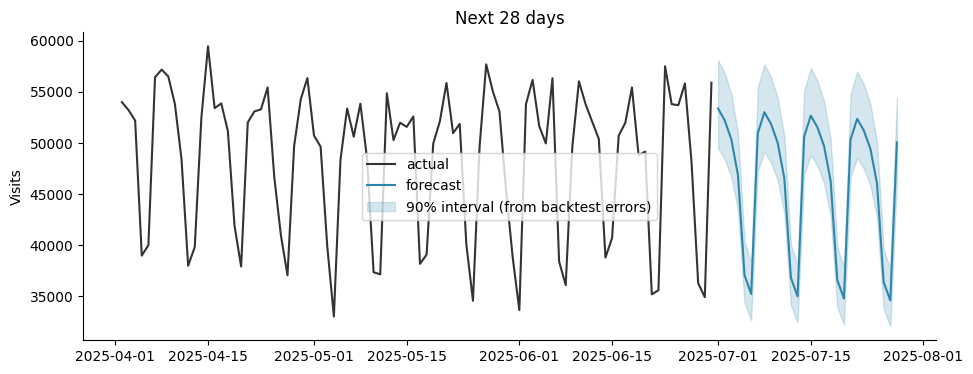

In [ ]:
errors = []
for cutoff in cutoffs:
    past = visits.loc[:cutoff]
    actual = visits.loc[cutoff + pd.Timedelta(days=1):].iloc[:HORIZON]
    errors.append(np.log(actual.to_numpy()) - np.log(calendar_regression(past, HORIZON)))
errors = np.array(errors)
low_q, high_q = np.percentile(errors, [5, 95])

future_index = pd.date_range(visits.index[-1] + pd.Timedelta(days=1), periods=HORIZON, freq="D")
future = calendar_regression(visits, HORIZON)
fig, ax = plt.subplots()
ax.plot(visits.iloc[-90:], color="#333", label="actual")
ax.plot(future_index, future, color="#2e86ab", label="forecast")
ax.fill_between(future_index, future * np.exp(low_q), future * np.exp(high_q), color="#2e86ab", alpha=0.2,
                label="90% interval (from backtest errors)")
ax.set(title="Next 28 days", ylabel="Visits")
ax.legend()
total = future.sum()
print(f"Next 28 days: about {total:,.0f} visits in total (range {total * np.exp(low_q):,.0f} "
      f"to {total * np.exp(high_q):,.0f} if every day erred the same way)")

The band comes from real past mistakes, so it reflects how this model
actually behaves. It doesn't cover surprises the past never contained, like
a viral launch or a major outage, so treat it as "normal conditions" only.

## Takeaways

- Fill gaps thoughtfully and keep a record of what you filled.
- Decompose the series first; most of the forecast is trend plus seasonality.
- Always compare against seasonal naive. Many fancy models fail to beat it.
- Tell the model about known events like launches and holidays.
- Backtest over many windows and look at the worst case, not just the average.
- Give ranges, not single numbers.